# PF-5039: Semana 01 - Práctica Asincrónica Desafío Avanzado
## Simulación de Aliasing Espacial, Filtro Antialiasing y Evaluación de PSNR en Retinografía

**Estudiante:** Franco Castro Chaves **Carné:** C01886

---
### Requerimientos del Desafío:
En esta práctica autónoma de 1 hora, estudiará en detalle cómo prevenir el fenómeno de Aliasing/Moiré en imágenes médicas de alta densidad cromática.

--- 
### Parte A: Simulación de Aliasing en una Grilla Sinusoidal Sintética
1. Genere una matriz de $512 \times 512$ píxeles representando la función matemática $f(x, y) = \sin(2\pi f_0 x) + \sin(2\pi f_0 y)$ con $f_0 = 15$.
2. Aplique un submuestreo por un factor de escala $S = 4$ mediante dos métodos:
   - **Método 1 (Submuestreo Directo sin Filtrado):** Tome cada $S$-ésimo píxel directo de la matriz (`pattern[::S, ::S]`).
   - **Método 2 (Submuestreo Filtrado Antialiasing):** Aplique un filtro pasa-bajo Gaussiano (`cv2.GaussianBlur`) con $\sigma = S/2 = 2.0$ y luego submuestree.
3. Grafique los 3 mapas de intensidad en paralelo e interpete la presencia de patrones Moiré.

Matriz original: (512, 512)
Submuestreo directo: (128, 128)
Submuestreo antialiasing: (128, 128)


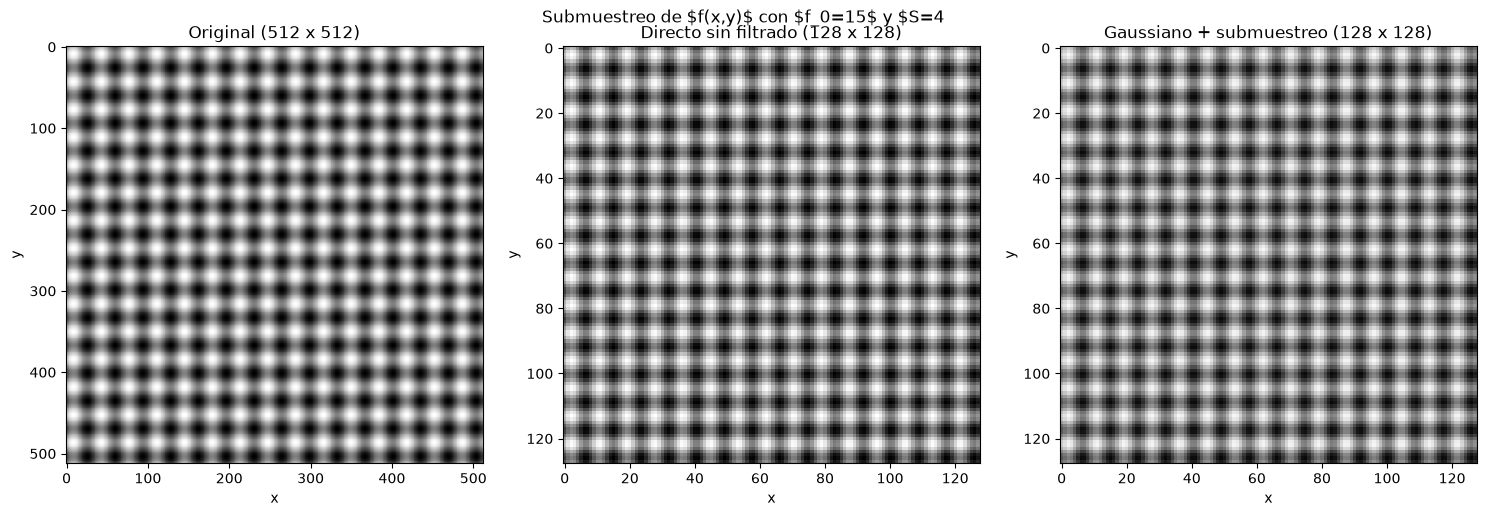

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
N = 512
f0 = 15
S = 4
sigma = S / 2

# Coordenadas normalizadas en el intervalo [0, 1)
x = np.linspace(0, 1, N, endpoint=False)
y = np.linspace(0, 1, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# Matriz de intensidad definida por f(x, y)
pattern = np.sin(2 * np.pi * f0 * X) + np.sin(2 * np.pi * f0 * Y)

# Método 1: submuestreo directo, sin filtrado
pattern_direct = pattern[::S, ::S]

# Método 2: filtro pasa-bajo Gaussiano antes del submuestreo
pattern_blurred = cv2.GaussianBlur(pattern, ksize=(0, 0), sigmaX=sigma)
pattern_antialiased = pattern_blurred[::S, ::S]

print(f"Matriz original: {pattern.shape}")
print(f"Submuestreo directo: {pattern_direct.shape}")
print(f"Submuestreo antialiasing: {pattern_antialiased.shape}")

# Comparación visual de la señal original y ambos métodos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [pattern, pattern_direct, pattern_antialiased]
titles = [
    "Original (512 x 512)",
    "Directo sin filtrado (128 x 128)",
    "Gaussiano + submuestreo (128 x 128)",
]

for axis, image, title in zip(axes, images, titles):
    axis.imshow(image, cmap="gray", vmin=-2, vmax=2, interpolation="nearest")
    axis.set_title(title)
    axis.set_xlabel("x")
    axis.set_ylabel("y")

fig.suptitle(r"Submuestreo de $f(x,y)$ con $f_0=15$ y $S=4")
plt.tight_layout()
plt.show()

### Interpretación de los patrones Moiré

En el mapa original se observa la suma de dos señales sinusoidales perpendiculares, con una frecuencia espacial de $f_0 = 15$ ciclos por unidad en las direcciones $x$ y $y$.

Al aplicar un submuestreo por un factor $S = 4$, la resolución pasa de $512 \times 512$ a $128 \times 128$ píxeles. La nueva frecuencia de Nyquist es de $64$ ciclos por unidad. Como $f_0 = 15 < 64$, la señal todavía puede representarse correctamente después del submuestreo. Por esta razón, en el **submuestreo directo** no se espera observar aliasing espacial significativo ni patrones Moiré pronunciados.

En el método **Gaussiano + submuestreo**, el filtro pasa-bajo suaviza la imagen antes de reducir su resolución. Sin embargo, dado que la frecuencia de la señal original ya se encuentra por debajo del nuevo límite de Nyquist, el filtrado antialiasing no produce una mejora sustancial en este caso. Su efecto principal es una ligera reducción del contraste y un suavizado de la señal.

Por lo tanto, para los parámetros utilizados, ambos métodos deberían producir resultados visualmente similares. Los patrones Moiré serían más evidentes si la frecuencia espacial de la señal fuera cercana o superior a $64$ ciclos por unidad.

--- 
### Parte B: Evaluación Cuantitativa de PSNR en Submuestreo de Retinografía
1. Cargue la imagen médica `retinografia_microaneurismas.png` ($512 \times 512$).
2. Reduzca la resolución espacial a $128 \times 128$ ($S=4$) mediante submuestreo directo y submuestreo con filtro Gaussiano.
3. Vuelva a escalar ambas imágenes reducidas a la dimensión original de $512 \times 512$ (`cv2.INTER_NEAREST`) para poder compararlas matriz a matriz con la original.
4. Calcule la métrica PSNR (dB) para ambos métodos y concluya cuál preserva mejor la fidelidad estructural de la vascularización retiniana.

Imagen original: (512, 512, 3)
Imagen reducida: (128, 128, 3)
PSNR submuestreo directo: 41.49 dB
PSNR Gaussiano + submuestreo: 41.52 dB


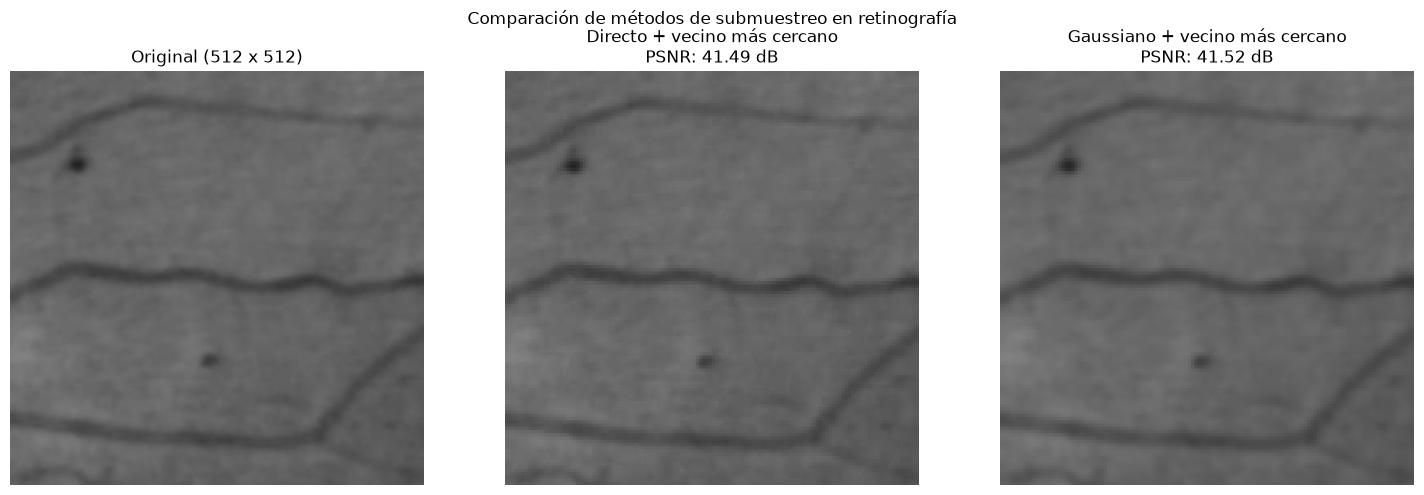

In [9]:
retinography = cv2.imread("imagenes/retinografia_microaneurismas.png")

S = 4
sigma = S / 2
original_height, original_width = retinography.shape[:2]
reduced_size = (original_width // S, original_height // S)
original_size = (original_width, original_height)

# Método 1: submuestreo directo
retinography_direct = retinography[::S, ::S]

# Método 2: filtrado Gaussiano y submuestreo
retinography_blurred = cv2.GaussianBlur(
    retinography,
    ksize=(0, 0),
    sigmaX=sigma,
)
retinography_antialiased = retinography_blurred[::S, ::S]

# Reescalado a la resolución original usando el vecino más cercano
retinography_direct_resized = cv2.resize(
    retinography_direct,
    original_size,
    interpolation=cv2.INTER_NEAREST,
)
retinography_antialiased_resized = cv2.resize(
    retinography_antialiased,
    original_size,
    interpolation=cv2.INTER_NEAREST,
)

# Cálculo de PSNR en decibelios
psnr_direct = cv2.PSNR(retinography, retinography_direct_resized)
psnr_antialiased = cv2.PSNR(retinography, retinography_antialiased_resized)

print(f"Imagen original: {retinography.shape}")
print(f"Imagen reducida: {retinography_direct.shape}")
print(f"PSNR submuestreo directo: {psnr_direct:.2f} dB")
print(f"PSNR Gaussiano + submuestreo: {psnr_antialiased:.2f} dB")

# Conversión de BGR a RGB para visualizar con Matplotlib
images = [
    cv2.cvtColor(retinography, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(retinography_direct_resized, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(retinography_antialiased_resized, cv2.COLOR_BGR2RGB),
]
titles = [
    "Original (512 x 512)",
    f"Directo + vecino más cercano\nPSNR: {psnr_direct:.2f} dB",
    f"Gaussiano + vecino más cercano\nPSNR: {psnr_antialiased:.2f} dB",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, image, title in zip(axes, images, titles):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

fig.suptitle("Comparación de métodos de submuestreo en retinografía")
plt.tight_layout()
plt.show()

### Conclusión de la Parte B

El submuestreo directo produce una imagen reconstruida con un PSNR de aproximadamente **41.49 dB**, mientras que el filtrado Gaussiano antes del submuestreo alcanza aproximadamente **41.52 dB**.

Por lo tanto, el método **Gaussiano + submuestreo** preserva ligeramente mejor la fidelidad estructural de la vascularización retiniana. La diferencia es pequeña porque la imagen no contiene suficiente aliasing para generar una mejora considerable; aun así, el filtro pasa-bajo reduce las variaciones de alta frecuencia antes de disminuir la resolución.